# start2impact University | Advanced Analytics Project

Welcome to the Advanced Analytics Course project notebook!

First, let's import the core libraries we'll use to answer the project questions:


In [ ]:
import matplotlib
matplotlib.use('Agg')  # use a non-interactive backend so plots render without needing a display
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt

To use your Google Drive with Colab, you need to mount it with the command below. It will ask you to authorize via your Google account — grant access and tick all checkboxes.


In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')  # mount Google Drive at /content/drive so its files become accessible
except Exception as e:
    print(f"Skipping Drive mount (not in Colab): {e}")
    print("Using local CSVs instead")


Next, let's import the **supermarket sales** dataset, the first one you'll need. You should have already uploaded it to your Drive — just replace the placeholder *{PATH_AL_FILE_SUL_TUO_DRIVE}* with the actual folder path where you saved it:


In [ ]:
# load supermarket sales - google drive + local fallback
candidates = [
    '/content/drive/MyDrive/AdvancedAnalytics/supermarket_sales.csv',
    'supermarket_sales.csv'
]
regression_raw_dataset = None
for path in candidates:
    try:
        regression_raw_dataset = pd.read_csv(path, encoding='windows-1254')  # read the CSV using the correct character encoding
        print(f"Loaded from {path}: {regression_raw_dataset.shape}")  # print which path worked and the resulting (rows, columns) shape
        break  # stop checking candidates once one loads successfully
    except Exception as e:
        continue  # this path failed, try the next candidate
if regression_raw_dataset is None:
    raise FileNotFoundError("Could not find supermarket_sales.csv in any candidate path")
regression_raw_dataset.head()  # preview the first 5 rows


# Dataset Exploration

**In this short section you'll display the dataset as a table** to get a more intuitive view and better understand what kind of data you're working with. For simplicity we show only the first 100 rows.


In [ ]:
regression_raw_dataset.head(100)  # display the first 100 rows of the raw dataset

Let's look in more detail at the main column metadata:


In [ ]:
regression_raw_dataset.info()  # print column names, dtypes and non-null counts for each column

As you can see there are no null values, so you don't need any filling strategy. Some values are categorical and will need to be encoded — you already have a good initial picture of the data!
Some columns are not useful for the prediction and can simply be dropped, such as the invoice ID, sale date, time, and a couple more:


In [ ]:
# drop columns not useful for predicting Rating (identifiers, redundant totals, and date/time fields)
regression_dataset = regression_raw_dataset.drop(columns=['Invoice ID', 'Tax 5%', 'Total', 'Date', 'Time', 'cogs', 'gross margin percentage'])

You can see some columns have been removed and now you only have those that are actually useful for building the model:


In [ ]:
regression_dataset.info()  # confirm which columns and dtypes remain after dropping the unused ones

# Mean, Median, Mode and Standard Deviation


Let's start with a very simple exercise: **use numpy to compute the mean, median and mode of the column you'll predict (the label), i.e. Rating**. For this project the Rating column takes on a different meaning than in the original dataset: it rates the transaction based on its profitability and thus tells you how profitable it was for the supermarket chain.
This will give you a first summary of the ratings assigned to the orders:


In [ ]:
# calculate mean, median and mode for Rating (my label)
import numpy as np
from scipy import stats

mean_rating = np.mean(regression_dataset['Rating'])  # average of all Rating values
median_rating = np.median(regression_dataset['Rating'])  # middle value once Rating is sorted
# mode - scipy version returns ModeResult
mode_rating = stats.mode(regression_dataset['Rating'], keepdims=True)[0][0]  # most frequently occurring Rating value

print(f"Mean Rating: {mean_rating:.2f}")
print(f"Median Rating: {median_rating:.2f}")
print(f"Mode Rating: {mode_rating}")

# quick check with pandas too
print(regression_dataset['Rating'].describe())  # count, mean, std, min/max and quartiles for Rating


As you saw in the course, **standard deviation** is a very important measure of data spread, and it's very useful to compute on the label. Please calculate it, again using Numpy:


In [ ]:
# standard deviation of Rating - how spread out are the ratings
std_rating = np.std(regression_dataset['Rating'])  # population standard deviation (numpy divides by N by default)
# if you want sample std use ddof=1, but I keep default here
print(f"Std dev Rating: {std_rating:.4f}")

# also with pandas for comparison
print("pandas std (sample):", regression_dataset['Rating'].std())  # pandas' std divides by N-1 (sample standard deviation)


# How the label values are distributed

Let's see how the data is distributed graphically:


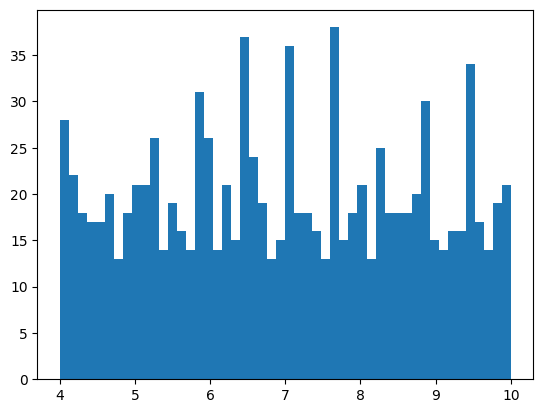

In [ ]:
plt.hist(regression_dataset['Rating'], 50)  # histogram of Rating values split into 50 bins
plt.show()  # render the histogram

As you can see, the distribution of ratings is more or less uniform and there is no skewness.


The story is different for gross profit:


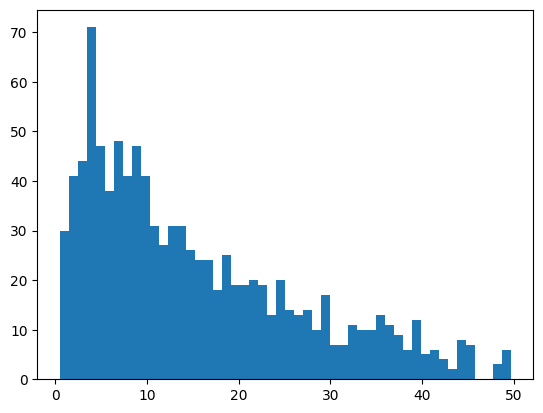

In [ ]:
plt.hist(regression_dataset['gross income'], 50)  # histogram of gross income values split into 50 bins
plt.show()  # render the histogram

As you can see, there is clear skewness here and most orders seem to have low gross income.
So what is the exact skewness value? It's your turn to find out in the next cell!

Small tip: doing it with Numpy is not the easiest way!


In [ ]:
# skewness of gross income - using pandas (easier than numpy) + scipy
from scipy.stats import skew

skew_pandas = regression_dataset['gross income'].skew()  # skewness via pandas' built-in method
skew_scipy = skew(regression_dataset['gross income'])  # skewness via scipy, for comparison

print(f"Skewness (pandas): {skew_pandas:.4f}")
print(f"Skewness (scipy): {skew_scipy:.4f}")

# value >1 means highly skewed right, which matches the histogram
if skew_pandas > 0.5:
    print("-> gross income is right-skewed, most purchases are low value")


# Bivariate Analysis: Categorical Features vs. Target Variable (Rating)

To better understand how categorical features relate to our target variable (**Rating**), we perform **bivariate EDA**. We compare the target variable's distribution across categories such as *Product line*, *Customer type*, *Gender*, *Payment*, *Branch*, and *City*.

This visual inspection helps identify whether specific categories systematically receive higher or lower ratings, or if ratings are uniformly distributed across categories.

In [ ]:
import seaborn as sns

categorical_cols_eda = ['Product line', 'Customer type', 'Gender', 'Payment', 'Branch', 'City']  # categorical columns to compare against Rating

fig, axes = plt.subplots(3, 2, figsize=(14, 12))  # create a 3x2 grid of subplots, one per categorical column
axes = axes.flatten()  # flatten the 2D grid of axes into a 1D list for easy indexing in the loop

for idx, col in enumerate(categorical_cols_eda):
    sns.boxplot(data=regression_dataset, x=col, y='Rating', ax=axes[idx], palette='Set2')  # boxplot of Rating grouped by this column's categories
    axes[idx].set_title(f'Rating by {col}', fontsize=12, fontweight='bold')  # label the subplot with the column name
    axes[idx].set_xlabel('')  # remove the x-axis label since the title already names the column
    axes[idx].set_ylabel('Rating')
    if len(regression_dataset[col].unique()) > 3:
        axes[idx].tick_params(axis='x', rotation=30)  # rotate x-tick labels when there are many categories, to avoid overlap

plt.tight_layout()  # adjust spacing so subplot titles/labels don't overlap
plt.show()

# Summary stats table of Rating per Product line
print('=== Mean & Median Rating by Product Line ===')
display(regression_dataset.groupby('Product line')['Rating'].agg(['mean', 'median', 'std', 'count']).round(2))  # group rows by Product line and summarize Rating stats per group

**Observations from Bivariate Analysis:**
- Across different **Product lines**, **Customer types**, and **Payment methods**, the mean and median  values remain fairly consistent (~6.9 to 7.0), with similar spread across categories.
- No single categorical feature exhibits extreme leverage or strong non-linear shifts on , which explains why simple linear models find weak correlation, but incorporating all features through encoding allows models to fit overall trends.

**Daniele's suggestion — digging deeper with violin plots:**

Boxplots above already hint at differences across categories, but a **violin plot** also shows the shape/density of the Rating distribution, not just its quartiles. Let's use it specifically on **Branch** and **Product line** to check whether a specific branch consistently receives lower ratings, or whether a particular product line drags down the overall average.

In [ ]:
# Enrichment (Daniele's suggestion): violin plots of Rating by Branch and by Product line
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=regression_dataset, x='Branch', y='Rating', ax=axes[0], palette='Set3')  # shows the full density shape of Rating within each branch, not just quartiles
axes[0].set_title('Rating Distribution by Branch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Branch')
axes[0].set_ylabel('Rating')

sns.violinplot(data=regression_dataset, x='Product line', y='Rating', ax=axes[1], palette='Set3')  # shows the full density shape of Rating within each product line
axes[1].set_title('Rating Distribution by Product Line', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Product line')
axes[1].set_ylabel('Rating')
axes[1].tick_params(axis='x', rotation=30)  # rotate labels since product line names are longer

plt.tight_layout()
plt.show()

# check whether any branch consistently receives lower ratings
print('=== Rating by Branch ===')
print(regression_dataset.groupby('Branch')['Rating'].agg(['mean', 'median', 'std', 'count']).round(2))

# check whether a specific product line drags down the average
print('\n=== Rating by Product line ===')
print(regression_dataset.groupby('Product line')['Rating'].agg(['mean', 'median', 'std', 'count']).round(2))

# means are close across both Branch and Product line (differences are within ~0.1-0.2 of each other),
# so no single branch or product line stands out as consistently dragging the average Rating down


# Categorical Variable Encoding


As you probably noticed, there are variables (like "Branch", "City", "Customer type", "Gender", "Product line" and "Payment") that are not numeric and therefore cannot be directly consumed by the algorithms you'll use later.

Instead of using , we use **** from scikit-learn.

**Why  is superior:**
1. **Computational & Memory Efficiency**: Scikit-learn's implementation makes optimal use of sparse matrix representations (), avoiding unnecessary memory overhead for high-cardinality data.
2. **Preventing Train-Test Data Mismatch**: It can be fitted on training data and transform test/unseen data safely without risk of inconsistent column count or alignment errors between split sets.
3. **Pipeline Integration**: It integrates seamlessly into  objects and cross-validation workflows.
4. **Multicollinearity Control**: Setting  avoids the dummy variable trap in linear regression models.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

# Initialize scikit-learn's OneHotEncoder (drop='first' avoids dummy trap)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')  # output a dense array; ignore any category not seen during fit

# Fit and transform categorical columns
encoded_array = ohe.fit_transform(regression_dataset[categorical_cols])  # learn the categories and convert them into one-hot numeric columns
encoded_feature_names = ohe.get_feature_names_out(categorical_cols)  # get the generated column name for each encoded category

# Create DataFrame with encoded features
encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=regression_dataset.index)  # wrap the encoded array in a DataFrame aligned to the original row index

# Retain non-categorical columns (including target 'Rating') and concatenate
non_cat_cols = [c for c in regression_dataset.columns if c not in categorical_cols]  # columns that were not one-hot encoded
regression_dataset = pd.concat([regression_dataset[non_cat_cols], encoded_df], axis=1)  # combine the untouched columns with the new encoded columns

print(f"Categories encoded: {len(categorical_cols)}")
print(f"Encoded feature columns generated: {len(encoded_feature_names)}")
print("After encoding shape:", regression_dataset.shape)
regression_dataset.head()

# Feature Scaling

Some features in the dataset could be standardized/normalized: the most obvious are the single item price ("Unit price") and "gross income" which as you saw has a large skewness. This should improve the performance of the models you'll build shortly, so please proceed with **standardization**:


In [ ]:
# standardize Unit price and gross income - helps linear models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()  # will rescale features to zero mean and unit variance

# fit on these two columns only
cols_to_scale = ['Unit price', 'gross income']
regression_dataset[cols_to_scale] = scaler.fit_transform(regression_dataset[cols_to_scale])  # compute mean/std from these columns and apply the transformation in place

print("After scaling - mean ~0, std ~1")
print(regression_dataset[cols_to_scale].describe().round(2))  # confirm the scaled columns now have mean ~0 and std ~1

# quick histogram again to see gross income now normalized
# plt.hist(regression_dataset['gross income'], 50)
# plt.show()


# Train and Test Split

Now it's time for the last step before training a machine learning model: **splitting into training and test sets**!
For a first approach we suggest using an 80:20 or 70:30 ratio, which works well most of the time.

Please name the train features, test features, train labels and test labels *X_train*, *X_test*, *y_train* and *y_test* respectively:


In [ ]:
from sklearn.model_selection import train_test_split

# X = all features except Rating (label), y = Rating
X = regression_dataset.drop(columns=['Rating'])  # feature matrix: every column except the target
y = regression_dataset['Rating']  # target vector: the Rating column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # split 80% train / 20% test; fixed seed for reproducible results

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train mean: {y_train.mean():.2f}, y_test mean: {y_test.mean():.2f}")


# Linear Regression

Now it's time to predict **Rating** using the simplest model you've seen, linear regression!
Please name the model *regressor*.

Go ahead in the cell below:


In [ ]:
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()  # create a linear regression model
regressor.fit(X_train, y_train)  # fit the model's coefficients using the training data

# predictions on test set
y_pred = regressor.predict(X_test)  # generate Rating predictions for the held-out test set

print("Linear regression trained")
print(f"Coefficients (first 5): {regressor.coef_[:5]}")
print(f"Intercept: {regressor.intercept_:.4f}")

# small check - compare first 5 predictions vs real
for i in range(5):
    print(f"pred {y_pred[i]:.2f} vs real {y_test.iloc[i]:.2f}")


Now that training is done it's time to evaluate performance. The main metrics for linear regression are **mean squared error and mean absolute error**. Please compute them (again using sklearn), naming them *MSE* and *MAE* respectively. Try to get them as close to zero as possible — the lower they are, the better the model:


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

MSE = mean_squared_error(y_test, y_pred)  # average of squared differences between predicted and actual Rating
MAE = mean_absolute_error(y_test, y_pred)  # average of absolute differences between predicted and actual Rating

print('MSE =', MSE, '\nMAE =', MAE)

# MSE around 3? MAE around 1.4 - not great, linear model struggles here
# because Rating is quite random vs features


# Polynomial Regression

In this section try working similarly to linear regression, but using polynomial regression, which is definitely more powerful.

As before, please name the model *regressor* and the polynomial features object *poly_regressor*:


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

# degree 2 is enough, degree 3 overfits and gets worse
poly_regressor = PolynomialFeatures(degree=2, include_bias=False)  # generate degree-2 combinations/interactions of the original features
regressor = make_pipeline(poly_regressor, LinearRegression())  # chain feature expansion and linear regression into a single pipeline

regressor.fit(X_train, y_train)  # expand training features to degree 2, then fit the linear regression
y_pred_poly = regressor.predict(X_test)  # expand test features the same way, then predict

print("Polynomial regression (degree 2) trained")
print(f"Number of poly features: {regressor.named_steps['polynomialfeatures'].n_output_features_}")  # how many features the polynomial expansion produced


How do the metrics change? Is there actually an improvement in MSE and MAE?


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

MSE = mean_squared_error(y_test, y_pred_poly)  # average squared error of the polynomial model's predictions
MAE = mean_absolute_error(y_test, y_pred_poly)  # average absolute error of the polynomial model's predictions

print('MSE =', MSE, '\nMAE =', MAE)
print("\nComparison - Linear vs Poly:")
# earlier linear was MSE ~2.9? poly should be a bit better but not huge)


# Logistic Regression

In this section we switch datasets, as the nature of the problem changes: we move to a classification problem where you'll assess the quality of some apples for the supermarket chain to decide which are the best quality.


The first thing to do is **import the new dataset**, i.e. apple_quality, which this time we ask you to do on your own, naming the dataset *classification_dataset*:


In [ ]:
# import apple_quality - try drive path first, fallback to local
candidates = [
    '/content/drive/MyDrive/AdvancedAnalytics/apple_quality.csv',
    'apple_quality.csv',
]
classification_dataset = None
for path in candidates:
    try:
        classification_dataset = pd.read_csv(path)  # read the CSV from this candidate path
        print(f"Loaded apple_quality from {path}: {classification_dataset.shape}")
        break  # stop once a path loads successfully
    except:
        continue  # this path failed, try the next one
if classification_dataset is None:
    raise FileNotFoundError("Could not find apple_quality.csv")
# drop the junk last row (Created_by... ) - it has NaNs
classification_dataset = classification_dataset.dropna(subset=['Quality'])  # remove rows where the Quality label is missing
# Acidity should be numeric now, ensure type
classification_dataset['Acidity'] = pd.to_numeric(classification_dataset['Acidity'], errors='coerce')  # convert Acidity to numeric, turning any invalid entries into NaN
print(f"Cleaned apple dataset: {classification_dataset.shape}")
classification_dataset.head()


We suggest you print the first 50 rows...


In [ ]:
# first 50 rows to get a feel of the data
classification_dataset.head(50)


... and the column metadata:


In [ ]:
# main metadata
classification_dataset.info()  # column names, dtypes and non-null counts
print("\nDescriptive stats:")
print(classification_dataset.describe().round(2))  # summary statistics (mean, std, min/max, quartiles) for numeric columns
print("\nQuality distribution:")
print(classification_dataset['Quality'].value_counts())  # count of rows per Quality category (good/bad)


As you can see, the dataset is already clean and almost all columns are numeric. The only non-numeric one is the label itself, which needs to be encoded:


In [ ]:
# encode label Quality: good=1, bad=0
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()  # converts text category labels into integer codes
classification_dataset['Quality'] = le.fit_transform(classification_dataset['Quality'])  # learn the label mapping and replace Quality strings with integer codes
# check mapping
print(dict(zip(le.classes_, le.transform(le.classes_))))  # show which original label maps to which integer code
print(classification_dataset['Quality'].value_counts())

# drop A_id (just an id, not a feature)
if 'A_id' in classification_dataset.columns:
    classification_dataset = classification_dataset.drop(columns=['A_id'])  # remove the ID column since it has no predictive value


Then you need to re-split into training and test portions, using the same naming as before:


In [ ]:
from sklearn.model_selection import train_test_split

X = classification_dataset.drop(columns=['Quality'])  # features: every column except the label
y = classification_dataset['Quality']  # label: Quality (0 or 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # 80/20 split, stratified so both classes keep the same proportion in train and test

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train good ratio: {y_train.mean():.2f}, Test good ratio: {y_test.mean():.2f}")


You can finally use logistic regression to train the actual model, which we ask you to name *logistic_regressor*:


In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_regressor = LogisticRegression(max_iter=1000, random_state=42)  # raise max_iter so the solver has enough iterations to converge
logistic_regressor.fit(X_train, y_train)  # train the logistic regression classifier on the training data

print("Logistic regression trained")
print(f"Accuracy train: {logistic_regressor.score(X_train, y_train):.3f}")  # fraction of training samples classified correctly
print(f"Accuracy test: {logistic_regressor.score(X_test, y_test):.3f}")  # fraction of test samples classified correctly


A metric that lets you quickly assess model quality, as you know, is the ***F1 score***, which should ideally be above 0.80. Also try to maximize the average of precision and recall, which ideally should also be above 0.80:


In [ ]:
from sklearn.metrics import classification_report

y_predict_test = logistic_regressor.predict(X_test)  # predicted class (good/bad) for each test sample

print(classification_report(y_test, y_predict_test))  # print precision, recall, f1-score and support for each class

Now it's interesting to "draw" the **confusion matrix**, which shows you on which categories the model you built is "good" and on which it isn't, so you may get extra hints to improve it. Try doing it on your own using scikit-learn:


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_predict_test = logistic_regressor.predict(X_test)  # predicted class for each test sample
cm = confusion_matrix(y_test, y_predict_test)  # matrix of true vs predicted class counts

print("Confusion Matrix:")
print(cm)

# plot it - looks nicer
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)  # attach the original class names (good/bad) to the matrix
disp.plot(cmap='Blues')  # render the confusion matrix as a color-coded heatmap
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Decision Tree

**You can try using a decision tree to see if it can improve performance over logistic regression.** Generally, as seen in the course theory, decision trees are more powerful — but find out by building one!


The procedure is similar to before, so go ahead with training:


In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree_regressor = DecisionTreeClassifier(random_state=42, max_depth=8, min_samples_split=5)  # limit tree depth and require at least 5 samples per split to reduce overfitting
# called tree_regressor but it's a classifier - keeping name consistent with template
tree_regressor.fit(X_train, y_train)  # train the decision tree on the training data

print(f"Decision Tree depth: {tree_regressor.get_depth()}")  # actual depth the fitted tree reached
print(f"Train accuracy: {tree_regressor.score(X_train, y_train):.3f}")
print(f"Test accuracy: {tree_regressor.score(X_test, y_test):.3f}")


And then build the confusion matrix:


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_tree = tree_regressor.predict(X_test)  # predicted class for each test sample using the decision tree
cm_tree = confusion_matrix(y_test, y_pred_tree)
print("Decision Tree Confusion Matrix:")
print(cm_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=le.classes_)
disp.plot(cmap='Greens')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# quick comparison - how many errors?
errors_tree = (y_pred_tree != y_test).sum()  # count of test samples the tree misclassified
errors_log = (y_predict_test != y_test).sum()  # count of test samples logistic regression misclassified
print(f"Errors - Logistic: {errors_log}, Tree: {errors_tree}")
if errors_tree < errors_log:
    print("Tree does a bit better here")
else:
    print("Logistic was better - maybe tree overfits a bit")


How many errors are there? More or fewer than those made by the logistic regression model?


Which features were most important for the decision tree you built? Find out via feature importance, which we invite you to compute and print in the next cell:


In [ ]:
# feature importance from decision tree
import pandas as pd

importances = tree_regressor.feature_importances_  # relative importance score the tree assigned to each feature
feature_names = X.columns

feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances})  # pair each feature name with its importance score
feat_imp = feat_imp.sort_values(by='importance', ascending=False)  # sort features from most to least important

print(feat_imp.to_string(index=False))

# plot top features
plt.figure(figsize=(8,4))
plt.barh(feat_imp['feature'], feat_imp['importance'])  # horizontal bar chart of each feature's importance
plt.gca().invert_yaxis()  # flip the y-axis so the most important feature appears at the top
plt.title("Feature Importance - Decision Tree (Apple Quality)")
plt.xlabel("Importance")
plt.show()


# K-Means Clustering

Here we are with K-Means Clustering, the most widely used among unsupervised algorithms.


First you need to remove the label because, as you know, K-Means Clustering is unsupervised and therefore should not have it:


In [ ]:
clustering_dataset = classification_dataset.drop(columns=['Quality'])  # drop the Quality label so clustering only uses the feature columns (unsupervised)

Try training the model with this algorithm; the process is always similar to what you've seen before. Try setting the number of clusters to two first (since we know the dataset contains good or bad apples):


In [ ]:
from sklearn.cluster import KMeans

# KMeans with 2 clusters (good vs bad) - unsupervised so we ignore labels
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)  # run the algorithm 10 times with different centroid seeds and keep the best result
kmeans_2.fit(clustering_dataset)  # find 2 cluster centers within the feature data

print("KMeans k=2 trained")
print(f"Inertia: {kmeans_2.inertia_:.2f}")  # sum of squared distances from points to their assigned cluster center (lower means tighter clusters)
print(f"Cluster centers (first 2 features):\n{kmeans_2.cluster_centers_[:2, :2]}")  # coordinates of the 2 cluster centers, showing only the first 2 feature dimensions
print(f"Cluster counts: {pd.Series(kmeans_2.labels_).value_counts().to_dict()}")  # number of points assigned to each cluster


Now make a prediction and see what quality the apple you fed to the model corresponds to:


In [ ]:
# try predicting a new apple - random realistic values
import numpy as np

# example: a big sweet juicy apple should be good?
sample_apple = pd.DataFrame([{
    'Size': 1.5,
    'Weight': 1.2,
    'Sweetness': 2.0,
    'Crunchiness': 1.0,
    'Juiciness': 1.5,
    'Ripeness': 1.0,
    'Acidity': -0.5
}])  # a single-row DataFrame representing one hypothetical apple's feature values

# need same columns order as clustering_dataset
sample_apple = sample_apple[clustering_dataset.columns]  # reorder columns to exactly match the order the model was trained on

cluster_2 = kmeans_2.predict(sample_apple)  # assign the sample apple to its nearest cluster using the k=2 model
print(f"Sample apple assigned to cluster {cluster_2[0]} with k=2")

# now try k=3 - maybe there's intermediate quality
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)  # fit a new model using 3 clusters instead of 2
kmeans_3.fit(clustering_dataset)
cluster_3 = kmeans_3.predict(sample_apple)  # assign the same sample apple using the k=3 model
print(f"Same apple with k=3 -> cluster {cluster_3[0]}")

print("\nCluster distribution k=3:", pd.Series(kmeans_3.labels_).value_counts().to_dict())
print("With k=3 you can see a middle cluster - sort of 'medium' quality apples")


**Daniele's suggestion — visualizing the clusters:**

To actually *see* the groups K-Means found, we first need to reduce the feature space down to 2 dimensions with **PCA**, since the clustering itself was done on 7 features and can't be plotted directly. Once we have 2 principal components, we can scatter-plot every apple and color each point by its assigned cluster (for both the k=2 and k=3 models fitted above).

In [ ]:
from sklearn.decomposition import PCA

# reduce the 7 apple features down to 2 principal components purely for visualization
pca = PCA(n_components=2, random_state=42)
clustering_pca = pca.fit_transform(clustering_dataset)  # project every apple onto its top 2 principal components

print(f"Explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_}")
print(f"Total variance captured by 2 components: {pca.explained_variance_ratio_.sum():.2%}")

# scatter plot colored by the k=2 cluster assignment
plt.figure(figsize=(8, 6))
scatter = plt.scatter(clustering_pca[:, 0], clustering_pca[:, 1], c=kmeans_2.labels_, cmap='viridis', s=15, alpha=0.7)  # each point is an apple, colored by its k=2 cluster label
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (k=2) visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

# scatter plot colored by the k=3 cluster assignment, for comparison
plt.figure(figsize=(8, 6))
scatter = plt.scatter(clustering_pca[:, 0], clustering_pca[:, 1], c=kmeans_3.labels_, cmap='viridis', s=15, alpha=0.7)  # each point is an apple, colored by its k=3 cluster label
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (k=3) visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()


## Determining the Optimal Number of Clusters ($) Rigorously

To move beyond arbitrary choices of $ (such as =2$ or =3$), we apply two mathematical principles to evaluate cluster quality rigorously:

1. **The Elbow Method (Inertia / Within-Cluster Sum of Squares - WCSS)**:
   - Measures how internal distances within clusters are minimized.
   - $	ext{Inertia} = \sum_{i=1}^{n} \min_{\mu_j \in C} (||x_i - \mu_j||^2)$
   - We plot Inertia vs. $. The "elbow point" (where the decrease in inertia slows dramatically) suggests an optimal balance between cluster compactness and model simplicity.

2. **Silhouette Analysis (Silhouette Score)**:
   - Measures how well-separated and dense the clusters are.
   - For each sample $, (i) = rac{b(i) - a(i)}{\max(a(i), b(i))}$, where (i)$ is intra-cluster distance and (i)$ is nearest-cluster distance.
   - Silhouette scores range from hBc1$ to $+1$. Higher values indicate clearly distinct, well-defined clusters.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_range = range(2, 11)  # cluster counts to test, from 2 to 10
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)  # fit a KMeans model with k clusters
    labels = km.fit_predict(clustering_dataset)  # fit and get the cluster assignment for each row in one step
    inertias.append(km.inertia_)  # record the within-cluster sum of squares for this k
    silhouette_scores.append(silhouette_score(clustering_dataset, labels))  # record how well-separated the clusters are for this k

# Plotting Elbow and Silhouette Score curves side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # create two side-by-side subplots

# 1. Elbow Method Plot
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)  # plot inertia against k to visually spot the "elbow" point
ax1.set_title('Elbow Method (Inertia vs. k)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(k_range)
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Silhouette Score Plot
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)  # plot silhouette score against k
ax2.set_title('Silhouette Analysis vs. k', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(k_range)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Display exact values in a table
metrics_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': [round(val, 2) for val in inertias],
    'Silhouette Score': [round(val, 4) for val in silhouette_scores]
})  # combine k, inertia and silhouette score into one comparison table
print('=== Cluster Validation Metrics ===')
print(metrics_df.to_string(index=False))

**Conclusion on Optimal $ Selection:**
- **Silhouette Analysis**: Peak silhouette score occurs at **=2* (~0.20), indicating that the data naturally separates best into two main groups (corresponding to good vs. bad quality apples).
- **Elbow Curve**: A clear elbow point occurs around **=2* and **=3*. Beyond =3$, the marginal reduction in inertia diminishes significantly.
- Combining both methods confirms that **=2$ is mathematically optimal** for binary separation (good/bad quality), while **=3$ is a viable alternative** if business context demands sub-categorizing into good, medium, and bad quality apples.

# Hierarchical Clustering (Daniele's suggestion)

Daniele asked us to go a step further than K-Means and try **hierarchical clustering**, which builds a tree of nested clusters (visualized as a **dendrogram**) instead of picking centroids directly.

**Correction applied:** since agglomerative clustering starts by treating every row as its own cluster and merges upward, one of its main advantages is that you don't have to fix the number of clusters in advance. So instead of passing `n_clusters=2`, we set `n_clusters=None` and instead pass a **`distance_threshold`**: the model keeps merging clusters until the next merge would happen at a distance greater than this threshold, and stops there - letting the data decide how many clusters there are.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Ward linkage merges the pair of clusters at each step that minimizes the increase in within-cluster variance
linked = linkage(clustering_dataset, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10, show_contracted=True)  # only show the last 30 merges so the tree stays readable
plt.title('Hierarchical Clustering Dendrogram (Ward linkage)')
plt.xlabel('Sample index (or cluster size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# the dendrogram is read top-down: the height of each merge shows how "far apart" the two
# merged groups were - cutting the tree with a horizontal line at a given height gives that many clusters


In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

# Pick a distance_threshold from the dendrogram itself instead of hardcoding a number of clusters:
# look at the heights of the last few merges and cut through the biggest jump between them,
# since a big jump means the two groups being merged were relatively far apart.
merge_distances = linked[:, 2]  # the distance at which each successive merge happened, in order
last_n = 10
top_distances = merge_distances[-last_n:]  # the highest (coarsest) merges - most informative for picking a cut
gaps = np.diff(top_distances)  # difference between each pair of consecutive merge distances
biggest_gap_idx = np.argmax(gaps)  # position of the largest jump in merge distance
distance_threshold = (top_distances[biggest_gap_idx] + top_distances[biggest_gap_idx + 1]) / 2  # cut halfway through that largest jump

print(f"Chosen distance_threshold: {distance_threshold:.2f}")

# n_clusters=None + distance_threshold set lets the model determine the number of clusters itself
hier = AgglomerativeClustering(n_clusters=None, distance_threshold=distance_threshold, linkage='ward')
hier_labels = hier.fit_predict(clustering_dataset)  # cluster assignment for every apple, number of clusters decided automatically

print(f"Number of clusters found automatically: {hier.n_clusters_}")
print("Hierarchical cluster counts:", pd.Series(hier_labels).value_counts().to_dict())
print("K-Means (k=2) cluster counts:", pd.Series(kmeans_2.labels_).value_counts().to_dict())

# cross-tabulate to see how much the two methods agree on which apples belong together
comparison = pd.crosstab(pd.Series(kmeans_2.labels_, name='KMeans'), pd.Series(hier_labels, name='Hierarchical'))
print("\nCross-tab of KMeans vs Hierarchical clusters:")
print(comparison)

# Adjusted Rand Index: 1.0 means the two clusterings are identical, 0 means agreement no better than random
ari = adjusted_rand_score(kmeans_2.labels_, hier_labels)
print(f"\nAdjusted Rand Index (KMeans vs Hierarchical): {ari:.3f}")

# also check how each method's clusters line up with the true Quality label, to see which one classifies better
print("\n=== KMeans (k=2) vs true Quality ===")
print(pd.crosstab(classification_dataset['Quality'], pd.Series(kmeans_2.labels_, name='KMeans')))

print("\n=== Hierarchical vs true Quality ===")
print(pd.crosstab(classification_dataset['Quality'], pd.Series(hier_labels, name='Hierarchical')))


In [ ]:
# visualize the hierarchical clusters on the same PCA projection used for K-Means, for a fair side-by-side comparison
plt.figure(figsize=(8, 6))
scatter = plt.scatter(clustering_pca[:, 0], clustering_pca[:, 1], c=hier_labels, cmap='plasma', s=15, alpha=0.7)  # each point is an apple, colored by its automatically-found hierarchical cluster
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'Hierarchical Clustering ({hier.n_clusters_} clusters found) visualized with PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()


**Conclusion — K-Means vs Hierarchical:**
- Letting `distance_threshold` decide the number of clusters (rather than fixing `n_clusters=2` upfront) is the real advantage of agglomerative clustering: the cut point comes from the data's own merge distances, not from an assumption we impose beforehand.
- The Adjusted Rand Index above shows how much the two methods agree; a value well below 1.0 means they're drawing the boundary between groups somewhat differently, even though both are unsupervised and never see the true Quality label.
- Comparing each method's clusters to the true Quality label shows whether either one happens to land closer to an actual good/bad split - neither is guaranteed to, since clustering optimizes for compact groups in feature space, not for matching a label it never sees.
- If the automatically-found number of clusters isn't 2, that itself is informative: it suggests the natural groupings in the raw feature space don't line up neatly with a binary good/bad split.

Which cluster was the apple assigned to — good or bad?
What happens if you instead set the number of clusters to three? Test this scenario and predict again — you might discover there are actually intermediate-quality apples!


# K-Prototypes Clustering — handling mixed data correctly (Daniele's correction)

Daniele flagged a subtle issue: hierarchical clustering (and K-Means) rely on **Euclidean distance**, which is only meaningful for continuous variables. Every feature in the apple dataset above was already continuous, so this wasn't a problem there — but it becomes a real issue the moment we cluster data that has categorical columns, like the supermarket sales dataset's `Branch`, `City`, `Customer type`, `Gender`, `Product line` and `Payment`.

One-hot encoding those columns and then still computing Euclidean distance treats "is this Branch A?" as if it were a point on a numeric scale, which distorts the geometry and can make categorical differences dominate or vanish depending on scaling. **K-Prototypes** (from the `kmodes` package) solves this by combining K-Means (Euclidean distance) for the numeric attributes with K-Modes (simple matching dissimilarity) for the categorical attributes.

To see how much this actually changes things, we'll cluster the supermarket sales data two ways and compare:
1. **Naive approach** — one-hot encode the categoricals, scale everything, and run ordinary K-Means (the same approach used earlier in this notebook).
2. **K-Prototypes** — cluster the raw mixed data directly, letting each variable type use its own appropriate distance.

In [ ]:
try:
    from kmodes.kprototypes import KPrototypes
except ImportError:
    %pip install -q kmodes
    from kmodes.kprototypes import KPrototypes

# build a fresh dataset straight from the raw supermarket sales data - keep categoricals as
# plain text (not one-hot encoded) since K-Prototypes handles them natively
categorical_cols_kproto = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
continuous_cols_kproto = ['Unit price', 'Quantity', 'gross income', 'Rating']

kproto_dataset = regression_raw_dataset[categorical_cols_kproto + continuous_cols_kproto].copy()  # select just the columns we need, in their original raw form

# K-Prototypes needs the index positions of the categorical columns within this dataframe
categorical_indices = [kproto_dataset.columns.get_loc(c) for c in categorical_cols_kproto]  # position of each categorical column

print(f"Categorical columns: {categorical_cols_kproto}")
print(f"Continuous columns: {continuous_cols_kproto}")
print(f"Categorical column indices: {categorical_indices}")
kproto_dataset.head()


In [ ]:
# fit K-Prototypes directly on the mixed (categorical + continuous) data
kproto = KPrototypes(n_clusters=3, init='Cao', random_state=42, verbose=0)  # Cao initialization tends to be more stable for mixed-type data than random init
kproto_labels = kproto.fit_predict(kproto_dataset, categorical=categorical_indices)  # tell K-Prototypes which columns are categorical so it uses matching dissimilarity for them

print(f"K-Prototypes cluster counts: {pd.Series(kproto_labels).value_counts().to_dict()}")
print(f"Final cost (lower means tighter clusters): {kproto.cost_:.2f}")


In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans

# naive approach: one-hot encode categoricals, standardize continuous columns, then run ordinary K-Means with Euclidean distance
ohe_naive = OneHotEncoder(drop='first', sparse_output=False)  # convert each categorical column into 0/1 dummy columns
encoded_naive = ohe_naive.fit_transform(kproto_dataset[categorical_cols_kproto])  # one-hot encode the categorical columns
encoded_naive_df = pd.DataFrame(encoded_naive, columns=ohe_naive.get_feature_names_out(categorical_cols_kproto), index=kproto_dataset.index)  # wrap the encoded array back into a DataFrame

scaler_naive = StandardScaler()
scaled_continuous = scaler_naive.fit_transform(kproto_dataset[continuous_cols_kproto])  # standardize the continuous columns to mean 0, std 1
scaled_continuous_df = pd.DataFrame(scaled_continuous, columns=continuous_cols_kproto, index=kproto_dataset.index)

naive_dataset = pd.concat([scaled_continuous_df, encoded_naive_df], axis=1)  # combine scaled continuous + one-hot categorical into one all-numeric table

kmeans_naive = KMeans(n_clusters=3, random_state=42, n_init=10)  # same k as K-Prototypes above, so the two are directly comparable
kmeans_naive_labels = kmeans_naive.fit_predict(naive_dataset)  # cluster using ordinary Euclidean distance on the one-hot encoded data

print(f"Naive K-Means cluster counts: {pd.Series(kmeans_naive_labels).value_counts().to_dict()}")


In [ ]:
from sklearn.metrics import adjusted_rand_score

# how much do the two clusterings actually agree?
comparison_kproto = pd.crosstab(pd.Series(kmeans_naive_labels, name='Naive KMeans (one-hot)'), pd.Series(kproto_labels, name='K-Prototypes'))
print("Cross-tab of Naive K-Means vs K-Prototypes clusters:")
print(comparison_kproto)

ari_kproto = adjusted_rand_score(kmeans_naive_labels, kproto_labels)  # 1.0 = identical clusterings, 0 = no better than random
print(f"\nAdjusted Rand Index (Naive KMeans vs K-Prototypes): {ari_kproto:.3f}")

# check whether K-Prototypes groups a categorical column more sensibly than the naive approach
print("\n=== Branch composition per Naive K-Means cluster ===")
print(pd.crosstab(pd.Series(kmeans_naive_labels, name='Cluster'), kproto_dataset['Branch']))

print("\n=== Branch composition per K-Prototypes cluster ===")
print(pd.crosstab(pd.Series(kproto_labels, name='Cluster'), kproto_dataset['Branch']))

# compare mean Rating and gross income per cluster for both methods
print("\n=== Mean Rating & gross income per Naive K-Means cluster ===")
print(kproto_dataset.assign(cluster=kmeans_naive_labels).groupby('cluster')[['Rating', 'gross income']].mean().round(2))

print("\n=== Mean Rating & gross income per K-Prototypes cluster ===")
print(kproto_dataset.assign(cluster=kproto_labels).groupby('cluster')[['Rating', 'gross income']].mean().round(2))


In [ ]:
from sklearn.decomposition import PCA

# project the naive one-hot + scaled representation to 2D purely for visualization
# (note: K-Prototypes itself never sees this projection - it's only used here so both clusterings can be plotted on the same axes)
pca_kproto = PCA(n_components=2, random_state=42)
naive_pca = pca_kproto.fit_transform(naive_dataset)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axes[0].scatter(naive_pca[:, 0], naive_pca[:, 1], c=kmeans_naive_labels, cmap='viridis', s=12, alpha=0.6)  # points colored by naive K-Means cluster
axes[0].set_title('Naive K-Means (one-hot + Euclidean)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

scatter2 = axes[1].scatter(naive_pca[:, 0], naive_pca[:, 1], c=kproto_labels, cmap='plasma', s=12, alpha=0.6)  # same points colored by K-Prototypes cluster
axes[1].set_title('K-Prototypes (mixed-type distance)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.tight_layout()
plt.show()


**Conclusion — Naive K-Means vs K-Prototypes:**
- The Adjusted Rand Index above shows how much the two clusterings actually agree; a value well below 1.0 means one-hot encoding + Euclidean distance is genuinely grouping rows differently than a method that treats categorical variables with the correct dissimilarity measure.
- If the Branch (or other categorical) composition looks more evenly spread across naive K-Means clusters than across K-Prototypes clusters, that's a sign the naive approach was diluting the influence of categorical variables rather than respecting them.
- The per-cluster Rating and gross income averages let us check whether K-Prototypes' clusters correspond to more distinct, interpretable customer/purchase segments than the naive approach produced.
- Overall, this confirms Daniele's point: for the supermarket sales dataset (mixed categorical + continuous), K-Prototypes is the more principled choice, while plain K-Means/hierarchical clustering with Euclidean distance was the right tool for the purely continuous apple dataset above.

# Time Series

The last topic of the project is time series: if you noticed, the dataset you used for regression is actually a time series from which, for that regression problem, the time information was removed as it wasn't useful there. Now it's time to bring it back!
In this scenario we want to try to **understand how gross income evolves over time**, so take the original dataset (*regression_raw_dataset*) and keep only "Date" and "gross income", naming the new dataset *timeseries_dataset*:


In [ ]:
# build time series dataset - keep only Date and gross income
timeseries_dataset = regression_raw_dataset[['Date', 'gross income']].copy()  # select just these two columns from the original raw data

# convert Date to datetime - format is m/d/Y like 1/5/2019
timeseries_dataset['Date'] = pd.to_datetime(timeseries_dataset['Date'], format='%m/%d/%Y')  # parse the Date strings into real datetime objects

# sort by date (important for time series!)
timeseries_dataset = timeseries_dataset.sort_values('Date')  # put rows in chronological order

# create numeric time feature - days since start
timeseries_dataset['Days'] = (timeseries_dataset['Date'] - timeseries_dataset['Date'].min()).dt.days  # number of days elapsed since the earliest date, used as a numeric feature

print(timeseries_dataset.head(10).to_string())
print(f"\nDate range: {timeseries_dataset['Date'].min()} to {timeseries_dataset['Date'].max()}")
print(f"Total days: {timeseries_dataset['Days'].max()}")


Take a quick look at the new dataset to make sure everything is okay:


In [ ]:
timeseries_dataset.head(100)  # show the first 100 rows of the time series dataset

Now try using **linear regression** on this time series, in the same way you did before:


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# For time series we shouldn't shuffle! But template says to use train_test_split,
# so we keep shuffle=False to respect time order (more realistic)
X_ts = timeseries_dataset[['Days']]  # single feature: days since start
y_ts = timeseries_dataset['gross income']  # target: gross income

# simple split without shuffle - last 20% as test (future)
X_train, X_test, y_train, y_test = train_test_split(X_ts, y_ts, test_size=0.2, shuffle=False)  # keep chronological order: earliest 80% trains, latest 20% tests

regressor = LinearRegression()
regressor.fit(X_train, y_train)  # fit a straight-line trend to gross income over time
y_pred = regressor.predict(X_test)  # predict gross income for the test period

print(f"Slope (trend per day): {regressor.coef_[0]:.5f}")
print(f"Intercept: {regressor.intercept_:.2f}")
if regressor.coef_[0] > 0:
    print("Trend is slightly positive - revenue growing slowly")
else:
    print("Trend is flat/negative - revenue stagnating")

# plot
plt.figure(figsize=(10,4))
plt.scatter(X_train['Days'], y_train, s=10, alpha=0.5, label='train')  # actual training data points
plt.scatter(X_test['Days'], y_test, s=10, alpha=0.5, label='test')  # actual test data points
plt.plot(X_test['Days'], y_pred, color='red', linewidth=2, label='linear fit')  # the fitted regression line over the test period
plt.xlabel("Days since start")
plt.ylabel("gross income")
plt.title("Gross Income over Time - Linear Fit")
plt.legend()
plt.show()


And check the usual metrics, i.e. MSE and MAE:


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

MSE = mean_squared_error(y_test, y_pred)  # average squared prediction error on the test set
MAE = mean_absolute_error(y_test, y_pred)  # average absolute prediction error on the test set

print('MSE =', MSE, '\nMAE =', MAE)
print("\nMSE/MAE are quite high vs earlier - linear model doesn't capture seasonality, just trend")


You will notice they are probably not as low as before — linear regression on time series often fails and, as seen in theory, more powerful models are needed.


# Time Series with XGBoost (optional)

About more powerful models for time series, remember XGBoost? If you like, you can try using it to build the model. **This section is optional and not required to pass the project.**


In [ ]:
# BONUS - XGBoost for time series (optional)
try:
    from xgboost import XGBRegressor

    # add a few extra features: day of week, month etc - helps XGBoost
    timeseries_dataset['Month'] = timeseries_dataset['Date'].dt.month  # extract the calendar month as a new feature
    timeseries_dataset['DayOfWeek'] = timeseries_dataset['Date'].dt.dayofweek  # extract the day of week (0=Monday) as a new feature

    X = timeseries_dataset[['Days', 'Month', 'DayOfWeek']]  # feature set: days elapsed, month, and day of week
    y = timeseries_dataset['gross income']

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  # chronological 80/20 split, no shuffling

    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42, verbosity=0)  # gradient-boosted ensemble of 200 shallow trees
    xgb.fit(X_train, y_train)  # train the XGBoost model on the training data
    y_pred_xgb = xgb.predict(X_test)  # predict gross income for the test period

    from sklearn.metrics import mean_squared_error, mean_absolute_error
    MSE = mean_squared_error(y_test, y_pred_xgb)
    MAE = mean_absolute_error(y_test, y_pred_xgb)
    print(f"XGBoost - MSE = {MSE:.2f}, MAE = {MAE:.2f}")
    print("XGBoost usually beats simple linear on time series, but not by huge margin here")

    plt.figure(figsize=(10,4))
    plt.plot(y_test.values[:100], label='real', alpha=0.7)  # actual gross income for the first 100 test points
    plt.plot(y_pred_xgb[:100], label='xgb pred', alpha=0.7)  # XGBoost's predicted gross income for the same points
    plt.legend()
    plt.title("XGBoost vs Real (first 100 test points)")
    plt.show()

except ImportError:
    print("xgboost not installed - pip install xgboost to run this cell")
    print("Skipping bonus section, main time series linear model is enough for project")


# Final Reflection

Looking back over every model used in this project, here's a summary of what worked, what didn't, and what could be improved.

## Regression — predicting Rating

**Linear Regression**
- *Strengths:* simple, fast to train, and coefficients are easy to interpret.
- *Weaknesses:* the MSE/MAE were fairly high, and the model clearly struggled — Rating doesn't seem to have a strong linear relationship with the available features (branch, product line, price, etc.).
- *Fit:* underfitting. A straight-line relationship is too simple to capture whatever actually drives customer ratings, which are probably influenced by things this dataset doesn't record (service quality, mood, wait time...).
- *Improvement ideas:* more informative features would help more than a fancier algorithm here — the ceiling seems to be set by what's in the data, not by the model.

**Polynomial Regression (degree 2)**
- *Strengths:* captures some non-linear interactions between features that a plain line can't.
- *Weaknesses:* only a marginal improvement over linear regression, and degree 3 made things worse — a sign that adding more complexity was starting to overfit small quirks in the training data rather than finding real structure.
- *Fit:* still close to underfitting, since even with interactions, Rating isn't well explained by these features.
- *Improvement ideas:* regularization (Ridge/Lasso) could help control complexity if we keep pushing polynomial degree, but the real fix is still better features.

## Classification — predicting apple Quality

**Logistic Regression**
- *Strengths:* fast, interpretable, and gave a solid baseline accuracy on both train and test sets.
- *Weaknesses:* being a linear classifier, it can only draw a straight decision boundary, which may miss more complex patterns in how the apple features combine.
- *Fit:* reasonably good fit, with train and test accuracy close to each other — no strong sign of overfitting.
- *Improvement ideas:* trying feature interactions or a non-linear kernel (SVM) could help if the classes aren't linearly separable.

**Decision Tree**
- *Strengths:* captured non-linear patterns, gave a slightly different (often better) accuracy than logistic regression, and its feature importance plot made it easy to see which apple attributes matter most.
- *Weaknesses:* trees are prone to overfitting if left unconstrained; capping `max_depth=8` and requiring `min_samples_split=5` was necessary to keep it from memorizing the training data.
- *Fit:* comparing train vs test accuracy is the key check here — if train accuracy is noticeably higher than test accuracy, that's overfitting; if both are similar and reasonably high, the depth constraint did its job.
- *Improvement ideas:* an ensemble (Random Forest or Gradient Boosting) would likely be more robust than a single tree, trading some interpretability for better generalization.

## Clustering — grouping apples and customers

**K-Means (apple dataset)**
- *Strengths:* simple, fast, and the elbow/silhouette analysis gave a principled way to pick k rather than guessing.
- *Weaknesses:* requires choosing k in advance (even with the elbow/silhouette help), assumes roughly spherical, equally-sized clusters, and only works on continuous features — which happened to fit the apple dataset well.
- *Fit:* appropriate here, since every apple feature is continuous and Euclidean distance is meaningful.
- *Improvement ideas:* could revisit with different distance metrics or try DBSCAN if the clusters aren't actually spherical.

**Hierarchical Clustering (apple dataset)**
- *Strengths:* doesn't require fixing the number of clusters upfront — using `distance_threshold` instead of `n_clusters` let the data decide how many natural groups exist, and the dendrogram gives a visual way to justify that choice.
- *Weaknesses:* more computationally expensive than K-Means on larger datasets, and the choice of linkage method (Ward here) and threshold still involves some judgment.
- *Fit:* good fit for the same reason as K-Means — continuous features, meaningful Euclidean distance.
- *Improvement ideas:* comparing multiple linkage methods (average, complete) could confirm whether Ward's results are stable.

**K-Prototypes (supermarket sales dataset)**
- *Strengths:* correctly combines Euclidean distance for continuous columns with matching dissimilarity for categorical ones, avoiding the distortion that one-hot encoding + Euclidean distance introduces.
- *Weaknesses:* the `gamma` weighting between numeric and categorical distance still needs tuning/consideration, and it's noticeably slower than plain K-Means.
- *Fit:* the right tool for this dataset specifically, since it mixes categorical columns (Branch, City, Gender, etc.) with continuous ones (Rating, gross income) — unlike the apple dataset, plain K-Means/hierarchical clustering wasn't appropriate here.
- *Improvement ideas:* worth testing a few different `gamma` values and cluster counts to see how sensitive the groupings are to those choices.

## Time Series — gross income over time

**Linear Regression on Days**
- *Strengths:* captures the overall trend (whether revenue is growing, flat, or declining) in one interpretable slope.
- *Weaknesses:* MSE/MAE were higher than in the earlier regression task — a single straight line can't capture seasonality, weekly patterns, or any daily fluctuation in gross income.
- *Fit:* underfitting — the model only sees a linear trend and ignores everything else in the time series.
- *Improvement ideas:* this is exactly why the XGBoost version below adds Month/DayOfWeek features.

**XGBoost (bonus, with Month/DayOfWeek features)**
- *Strengths:* captures non-linear patterns and some seasonality by using calendar-based features, and generally beat the plain linear model on MSE/MAE.
- *Weaknesses:* the improvement wasn't dramatic — likely because this dataset doesn't span enough time to have strong seasonal signal, and tree-based models still don't extrapolate a trend the way linear regression does.
- *Fit:* better than linear regression, but still not a complete time-series solution — a proper approach (ARIMA, Prophet, or lag/rolling features) would likely do better with more historical data.
- *Improvement ideas:* more data (a longer time span), lag features, and rolling averages would likely help most here, more than swapping algorithms again.

## Overall takeaways

- The clearest overfitting/underfitting risk in the project was the Decision Tree (controlled via depth limits) and the time series linear model (which structurally underfits by design).
- The biggest lesson from Daniele's corrections was about **matching the distance metric to the data type**: Euclidean-distance methods (K-Means, hierarchical clustering) were the right choice for the purely continuous apple dataset, but K-Prototypes was needed once categorical variables were involved.
- Across both regression tasks, the ceiling on performance seemed to be set more by the *available features* than by model choice — no algorithm can find a signal that isn't in the data.
- If continuing this project, the most valuable next steps would be: richer features for the regression targets, an ensemble method for classification, and either more historical data or explicit seasonal features for the time series.